# Choosing a location for a well

Let's say you work for the mining company GlavRosGosNeft. We need to decide where to drill a new well.

You were provided with oil samples in three regions: in each 100,000 fields, where the quality of oil and the volume of its reserves were measured. Build a machine learning model that will help determine the region where mining will bring the greatest profit. Analyze the possible profits and risks using the *Bootstrap.* technique

Steps to select a location:

- Deposits are searched for in the selected region, and the characteristic values are determined for each;
- Build a model and estimate the volume of reserves;
- Deposits with the highest estimated values ​​are selected. The number of fields depends on the company’s budget and the cost of developing one well;
- Profit is equal to the total profit of the selected fields.

## Loading and preparing data

In [1]:
# importing necessary libraries and modules
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import mean_squared_error

### Loading Data

In [2]:
# create a list with files and an empty list for future dataframes
files = ['/datasets/geo_data_0.csv', '/datasets/geo_data_1.csv', '/datasets/geo_data_2.csv']
geo_datas = []

In [3]:
# add all dataframes to the geo_datas list
for file in files:
    geo_data = pd.read_csv(file, index_col='id')
    geo_datas.append(geo_data)

In [4]:
# display the first 5 lines for each dataframe and information about each dataframe
for geo_data in geo_datas:
    print(geo_data.head())
    print()
    geo_data.info()
    print('\n')

             f0        f1        f2     product
id                                             
txEyH  0.705745 -0.497823  1.221170  105.280062
2acmU  1.334711 -0.340164  4.365080   73.037750
409Wp  1.022732  0.151990  1.419926   85.265647
iJLyR -0.032172  0.139033  2.978566  168.620776
Xdl7t  1.988431  0.155413  4.751769  154.036647

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, txEyH to 1CWhH
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   f0       100000 non-null  float64
 1   f1       100000 non-null  float64
 2   f2       100000 non-null  float64
 3   product  100000 non-null  float64
dtypes: float64(4)
memory usage: 3.8+ MB


              f0         f1        f2     product
id                                               
kBEdx -15.001348  -8.276000 -0.005876    3.179103
62mP7  14.272088  -3.475083  0.999183   26.953261
vyE1P   6.263187  -5.948386  5.001160  134.766305
KcrkZ -13.081196 -11.506057 

### Data preprocessing

In [5]:
# check for obvious duplicates in dataframes
for geo_data in geo_datas:
    print(geo_data.duplicated().sum())

0
0
0


In [6]:
# divide the data into input and target features
X_list = []
y_list = []

for geo_data in geo_datas:
    X_list.append(geo_data.drop('product', axis=1))
    y_list.append(geo_data['product'])

All values ​​in the columns are numeric, which means we will prepare the data using scaling

### Exploratory data analysis

In [7]:
# Let's create a function for exploratory data analysis
def analyze_distribution(data, column):
    name = (column
        .replace('_', ' ')
        .capitalize())

    data[column].hist(bins=20, color='#F5C6AA')
    plt.xlabel(name)
    plt.ylabel('Number of employees')
    plt.title(f'Распределение колонки "{name}"')  
    plt.show()

    print(data[column].describe())

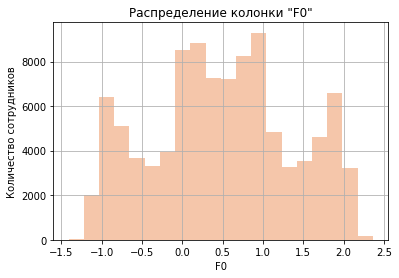

count    100000.000000
mean          0.500419
std           0.871832
min          -1.408605
25%          -0.072580
50%           0.502360
75%           1.073581
max           2.362331
Name: f0, dtype: float64


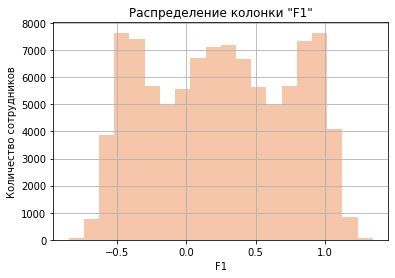

count    100000.000000
mean          0.250143
std           0.504433
min          -0.848218
25%          -0.200881
50%           0.250252
75%           0.700646
max           1.343769
Name: f1, dtype: float64


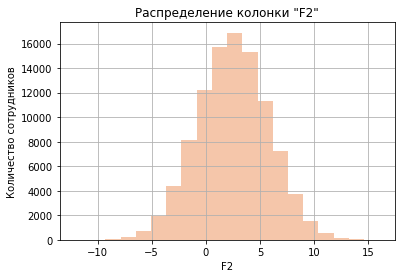

count    100000.000000
mean          2.502647
std           3.248248
min         -12.088328
25%           0.287748
50%           2.515969
75%           4.715088
max          16.003790
Name: f2, dtype: float64


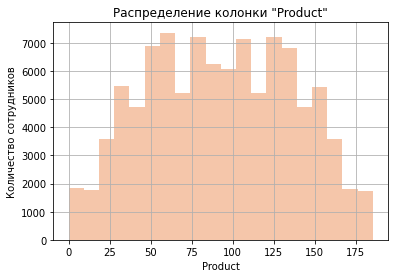

count    100000.000000
mean         92.500000
std          44.288691
min           0.000000
25%          56.497507
50%          91.849972
75%         128.564089
max         185.364347
Name: product, dtype: float64


In [8]:
# consider the distribution of features in the 1st region
for column in geo_datas[0].columns:
    analyze_distribution(geo_datas[0], column)

Description of the distribution of features in the 1st region

Sign F0:
  - Range: −1.41 to 2.36; mean 0.50, median 0.50, σ≈0.87.
  - The distribution is wide, with several peaks; close to symmetrical, slight right-sided asymmetry. There are extreme values, but the tails are moderate.

Sign F1:
  - Range: −0.85 to 1.34; mean 0.25, median 0.25, σ≈0.50.
  - Almost symmetrical, closer in shape to “sawtooth-uniform” with several peaks; There are few pronounced tails and outliers.

Sign F2:
  - Range: from −12.09 to 16.00; mean 2.50, median 2.52, σ≈3.25.
  - Close to a normal bell, center ~2.5; the right tail is slightly longer. Outliers are observed.

Product
  - Range: from 0 to 185.36; mean 92.5, median 91.85, σ≈44.29.
  - Almost uniform throughout the entire range, without obvious asymmetry; values ​​are limited to hard edges 0 and ~185.

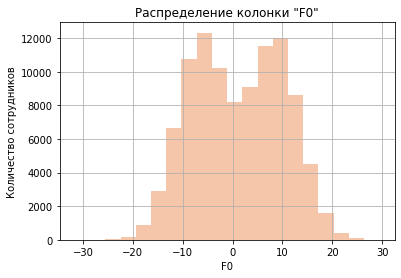

count    100000.000000
mean          1.141296
std           8.965932
min         -31.609576
25%          -6.298551
50%           1.153055
75%           8.621015
max          29.421755
Name: f0, dtype: float64


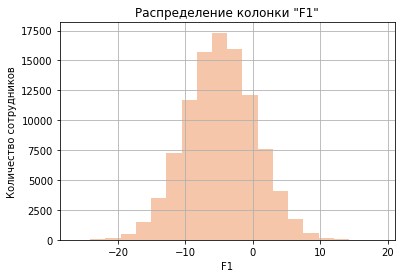

count    100000.000000
mean         -4.796579
std           5.119872
min         -26.358598
25%          -8.267985
50%          -4.813172
75%          -1.332816
max          18.734063
Name: f1, dtype: float64


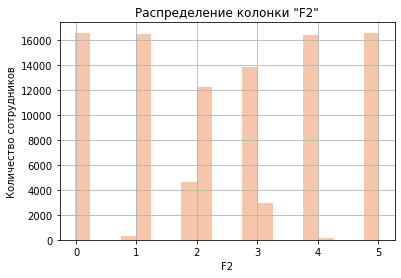

count    100000.000000
mean          2.494541
std           1.703572
min          -0.018144
25%           1.000021
50%           2.011479
75%           3.999904
max           5.019721
Name: f2, dtype: float64


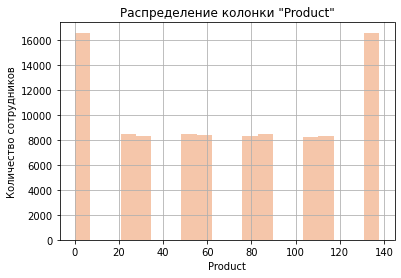

count    100000.000000
mean         68.825000
std          45.944423
min           0.000000
25%          26.953261
50%          57.085625
75%         107.813044
max         137.945408
Name: product, dtype: float64


In [9]:
# consider the distribution of features in the 2nd region
for column in geo_datas[1].columns:
    analyze_distribution(geo_datas[1], column)

Description of the distribution of features in the 2nd region

Sign F0:
  - Range: −31.6 to 29.4; mean 1.14, median 1.15, σ≈8.97.
  - Very wide spread, heavy tails. The histogram shows multimodality (several peaks around −10 and +8…10). Slight skew to the right.

Sign F1:
  - Range: −26.4 to 18.7; mean −4.80, median −4.81, σ≈5.12.
  - Almost “bell” with a center around −5, the right tail is longer (moderate right-sided asymmetry).

Sign F2:
  - Range: 0 to 5; mean 2.49, median 2.01, σ≈1.70.
  - Discrete/ordinal feature with mass on integer values ​​0–5 (stepped histogram); the distribution is close to uniform across levels.

Product:
  - Range: from 0 to 137.95; mean 68.83, median 57.09, σ≈45.94.
  - Multimodal/graded distribution (pronounced peaks at ~20–30 units), weak right-sided asymmetry. The range is narrower and the levels are lower than in the 1st region.
  
The distributions of features F2 and product look quite strange, let's study these columns in more detail

In [10]:
# count the number of unique values ​​in column 'f2'
geo_datas[1]['f2'].nunique()

100000

All values ​​in a column are unique, so you can simply look at the histogram with the smaller bins value

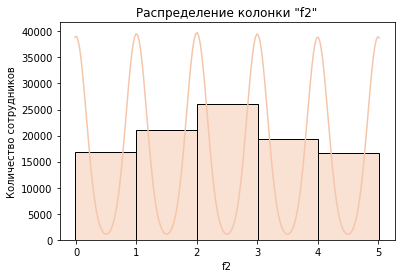

In [12]:
sns.histplot(geo_datas[1]['f2'], bins=5, kde=True, color='#F5C6AA')
plt.xlabel('f2')
plt.ylabel('Number of employees')
plt.title(f'Распределение колонки "f2"')  
plt.show()

The new histogram shows a distribution similar to normal

In [ ]:
# count the number of unique values ​​in column 'f2'
geo_datas[1]['product'].nunique()

There are only 12 unique values ​​in the 'product' column, let's build a bar chart for analysis

In [ ]:
counts = geo_datas[1]['product'].value_counts().sort_index()
counts.plot(kind='bar', color='#F5C6AA')
plt.xlabel('Product')
plt.ylabel('Number of employees')
plt.title(f'Распределение колонки "Product"')
plt.show()

All 12 values ​​occur approximately the same number of times, but in any case the distribution of profits is quite suspicious; in reality, it is unlikely that 8,000 wells could have the same amount of raw materials up to the 10th decimal place. If possible, it is better to check the data

In [ ]:
# consider the distribution of features in the 3rd region
for column in geo_datas[2].columns:
    analyze_distribution(geo_datas[2], column)

Description of the distribution of features in the 3rd region

Sign F0:
  - Range: −8.76 to 7.24; average 0.00; median 0.01; σ≈1.73.
  - Almost normal distribution, center near zero; symmetrical. The spread is moderate; there are rare emissions in the tails.

Sign F1:
  - Range: −7.08 to 7.84; mean −0.00; median −0.01; σ≈1.73.
  - Almost identical in shape and scale to F0: bell-shaped, well centered on 0. A slightly longer right tail is possible.

Sign F2:
  - Range: −11.97 to 16.74; average 2.50; median 2.48; σ≈3.47.
  - The distribution is shifted to the right (most values ​​> 0), the scatter is noticeably greater than that of F0/F1; tails are heavier, weak right-sided asymmetry.

Product:
  - Range: from 0 to ≈190; average 95.00; median 94.93; σ≈44.75.
  - Almost “flat” distribution with undulation/soft multimodality; There is no pronounced asymmetry. The range is wider and the levels are higher than in the 2nd region.

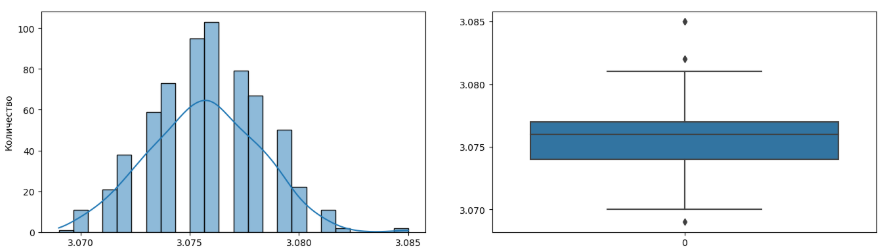

def plot_hist(data, col_column):
    '''
    Function for drawing histograms and box-whiskers for quantitative variables.
    Input: source table and list of quantitative variables.
    Output: graphs
    '''
    rows = len(col_column)
    f, ax = plt.subplots(rows,2, figsize=(8, 15))
    f.tight_layout()
    f.set_figheight(30)
    f.set_figwidth(14)
    plt.rcParams.update({'font.size': 18})
    
    for i, col in enumerate(col_column):         
        sns.histplot(data[col], kde=False, bins=24, ax = ax[i, 0])                    
        sns.boxplot(data[col], ax = ax[i, 1])

        ax[i, 0].set_xlabel(col)
        ax[i, 1].set_xlabel(col)
        ax[i, 0].set_ylabel('Quantity')
    plt.suptitle("Histogram and whisker box for quantitative data", fontsize=22, y=1.01)
    plt.show()

### Correlation data analysis

1-й регион


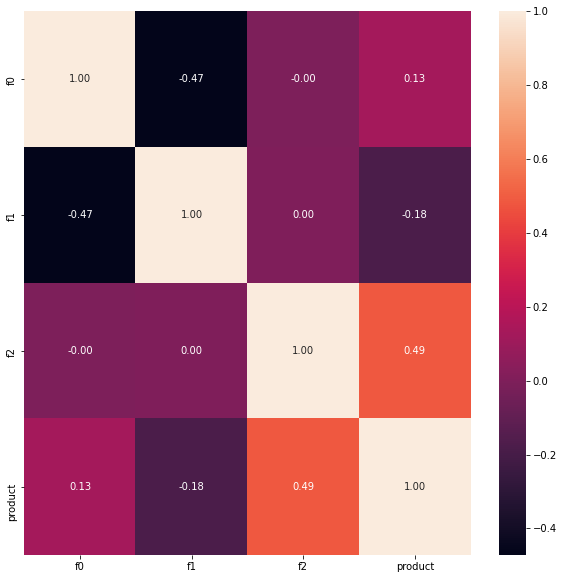

2-й регион


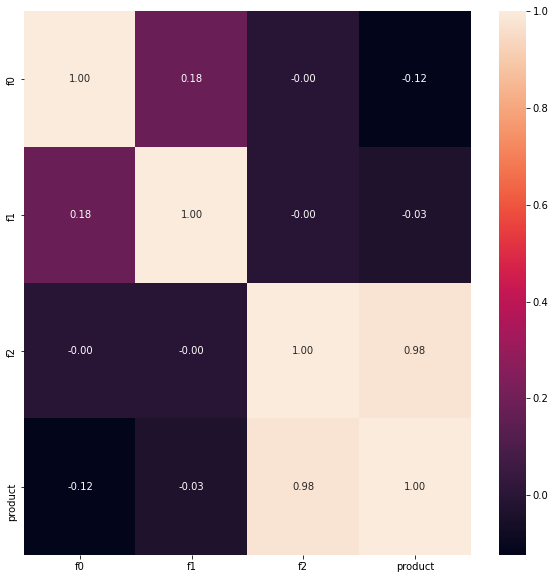

3-й регион


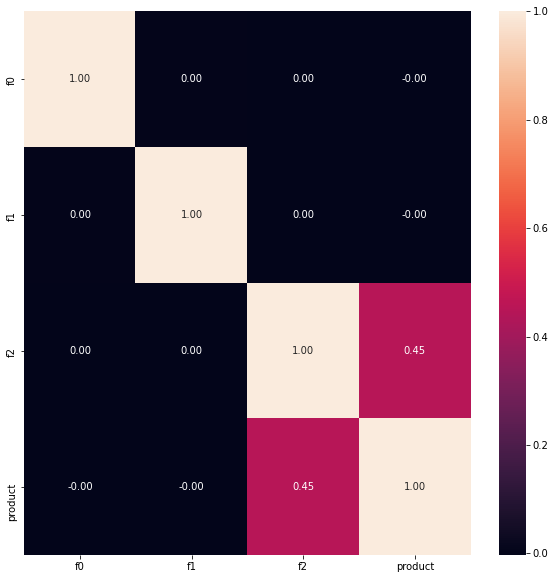

In [13]:
# build correlation matrices for dataframes
for i, geo_data in enumerate(geo_datas):
    print(f'{i+1}th region')
    plt.figure(figsize=(10, 10))
    sns.heatmap(geo_data.corr(method='spearman'), annot=True, fmt='.2f')
    plt.show()

For all regions, the highest correlation is observed with the f2 trait, but in the second region it reached a maximum value of one, which is again suspicious; the data must be double-checked!

Multicollinearity is not observed in any region

In [ ]:
# Let's create a function to build a scatter diagram
def scatter_plot(data, column):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=column, y='product', data=data, s=100)
    plt.title(
        f'Scatterplot for product and {column} attributes' 
       )
    plt.grid(True)
    plt.show()

In [ ]:
# construct scatter diagrams for the target feature from the input features
for i, geo_data in enumerate(geo_datas):
    print(f'{i+1}th region')
    for column in X_list[0].columns:
        scatter_plot(geo_data, column)

The scatter diagrams showed the same result as the Scatter diagrams showed the same result as the correlation matrix: there is no dependence between the characteristics product and f0, f1, there is a direct correlation between product and f2, for the second region it is equal to 1.

###Conclusion:
- In all regions, the target value (product) is practically not related to F0/F1 and is significantly related to F2; There is no multicollinearity.
- Region 1: distributions look natural; F0/F1 are close to symmetrical, F2 is almost normal with a slight right tail; product is almost uniformly distributed within the range 0–≈185.
- Region 2: signs are anomalous - F0/F1 with a very wide spread and multimodality, F2 is discrete (0–5), product has only ~12 levels with almost equal frequencies; the product–F2 correlation is 1. The range and levels of product are lower than in region 1. The data requires verification.
- Region 3: F0/F1 are well centered around zero and close to normal; F2 is shifted to the right and is more variable; product is wide and almost “flat” up to ≈190.
- Graphs and correlations are consistent: clear direct relationship only between product and F2.
- Practically: F2 is the key input feature; for the 2nd region, a data audit or separate modeling is needed; take into account rare outliers and strict target boundaries.

In [ ]:
# creating a pipeline for preparing data and training the model
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

## Training and checking models

In [ ]:
# let's set constants
test_size = 0.25
RANDOM_STATE = 42

In [ ]:
# divide the data into test and validation samples
X_train_list = []
X_valid_list = []
y_train_list = []
y_valid_list = []

for X, y in zip(X_list, y_list):
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=test_size, random_state=RANDOM_STATE)
    X_train_list.append(X_train)
    X_valid_list.append(X_valid)
    y_train_list.append(y_train)
    y_valid_list.append(y_valid)

In [ ]:
# train the model using training data
model_list = []

for X_train, y_train in zip(X_train_list, y_train_list):
    model = clone(pipe)
    model.fit(X_train, y_train)
    model_list.append(model)

In [ ]:
# let's keep the predictions
predictions_list = []

for model, X_valid in zip(model_list, X_valid_list):
    predictions = model.predict(X_valid)
    predictions_list.append(predictions)

In [ ]:
# save the dataframes with y_valid and y_pred
valid_pred_datas = []

for predictions, y_valid in zip(predictions_list, y_valid_list):
    y_pred = pd.Series(predictions, index=y_valid.index)
    data = pd.DataFrame({'y_valid': y_valid, 'y_pred': y_pred})
    valid_pred_datas.append(data)

In [ ]:
# print the first 5 rows of each dataframe and the average values ​​for y_valid and y_pred
y_pred_mean = []

for data in valid_pred_datas:
    print(data.head())
    print()
    print('y_valid: ', data['y_valid'].mean())
    print('y_pred:  ', data['y_pred'].mean())
    y_pred_mean.append(data['y_pred'].mean())
    print('\n')

In [ ]:
# let's create a list with rmse
rmse_list = []

for y_valid, predictions in zip(y_valid_list, predictions_list):
    rmse = mean_squared_error(y_valid, predictions, squared=False)
    rmse_list.append(rmse)

In [ ]:
# let's create a table with rmse
res_data = pd.DataFrame({'region': range(1, 4), 'rmse': rmse_list, 'y_pred_mean': y_pred_mean})
res_data

###Conclusion:

The second region has the smallest average stock of raw materials, but rmse is also the smallest and is only 0.89 compared to 37.7 and 40.1 for the first and third regions. In the first and third regions, average reserves are close in value, but in the third region they are slightly higher: 95 compared to 92.

## Preparation for profit calculation

In [ ]:
# let's create variables with constants
N_EXPLORE = 500
N_BEST = 200
BUDJET = 10e9
BARREL_INCOME = 450000
RISK_OF_LOSS = 0.025

In [ ]:
# we will calculate a sufficient volume of raw materials for break-even well development
BUDJET_PER_WELL = BUDJET/N_BEST
MIN_PRODUCT = BUDJET_PER_WELL/(BARREL_INCOME)

In [ ]:
MIN_PRODUCT

###Conclusion:
The minimum amount of raw materials for break-even development of a well is 111 thousand barrels, which is more than the average reserve values in each region, which means that for development it is necessary to select the highest quality and profitable wells

## Calculation of profits and risks

In [ ]:
# let's write a function to calculate profit
def profit(y_valid, y_pred, n_best, barrel_income, budjet):
    y_pred_sort = y_pred.sort_values(ascending=False)
    product_sum = y_valid[y_pred_sort.index][:n_best].sum()
    return product_sum * barrel_income - budjet

In [ ]:
state = np.random.RandomState(12345)

In [ ]:
# let's create a function to perform bootstrap
def bootstrap(y_pred, y_valid, n_best, n_explore, barrel_income, budjet):
    values = []
    for i in range(1000):
        subsample = y_pred.sample(n=n_explore, replace=True, random_state=state)
        values.append(profit(y_valid, subsample, n_best, barrel_income, budjet))
    return values

In [ ]:
# let's create a function to calculate the confidence interval
def trust_interval(values, percent):
    values = pd.Series(values)
    lower = values.quantile((1 - percent) / 2)
    upper = values.quantile(1 - ((1 - percent) / 2))
    return lower, upper

In [ ]:
# let's create a function to calculate the probability of risk
def risk_probability(values):
    m = sum(x < 0 for x in values)
    risk = m / len(values)
    return risk

In [ ]:
for i, data in enumerate(valid_pred_datas):
    profits = bootstrap(data['y_pred'], data['y_valid'], N_BEST, N_EXPLORE, BARREL_INCOME, BUDJET)
    print(f'{i+1}th region')
    print('Average revenue:', np.mean(profits))
    print('Confidence interval:', trust_interval(profits, 0.95))
    print('Probability of risk:', risk_probability(profits))
    print('\n')

##Conclusion:
In this project, I carried out a full cycle of analysis to select the most profitable drilling region. First, I downloaded and prepared data for three regions: I checked the correctness, identified the characteristics and the target variable (reserves). For each region, I divided the sample in a ratio of 75/25 into training and validation, trained regression models, obtained predictions for validation, saved predictions and actual values, estimated average predicted reserves and RMSE, and made sure that the quality of the models was sufficient for economic calculations.

Next, I recorded the key parameters of the project’s economics and calculated the break-even threshold for the volume of raw materials: 111 thousand barrels per well. Since this threshold exceeds the average reserves in each region, I chose a targeted selection strategy - to take for development only the highest quality wells in the upper tail of the distribution of model predictions. To do this, I implemented a profit calculation function: I selected top wells based on predictions, summed up the corresponding actual reserves and calculated the project’s revenue/profit.

To estimate uncertainty, I applied Bootstrap with 1000 iterations and obtained profit distributions by region. The results are:
- 1st region: average revenue 400,800,107; 95% interval (−86,233,106; 892,569,802); risk of loss 5.6%.
- 2nd region: average revenue 447,023,953; 95% interval (38,081,198; 844,433,615); risk of loss 1.5%.
- 3rd region: average revenue 373,016,785; 95% interval (−120,329,867; 886,389,839); risk of loss 8.0%.

Based on these results, I recommend region 2 for development. It provides the highest expected revenue with the lowest risk of loss, and the lower bound of the 95% confidence interval is positive. Given the break-even threshold of 111 thousand barrels and the fact that average reserves are below the threshold, I will select for drilling only wells with the highest predicted reserves in the 2nd region - this maximizes the likelihood of reaching and exceeding the break-even point and increases the sustainability of the economic result of the project.

Place an 'x' in the completed items. Next, press Shift+Enter.